# Bluestock Mutual Fund Analytics

## Exploratory Data Analysis (EDA)

Prepared by:
Pranav Shinde

Project:
Capstone Project I – Mutual Fund Analytics

Tools Used
- Python
- Pandas
- Plotly
- Seaborn
- Matplotlib
- SQLite

In [12]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [13]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
fund = pd.read_csv("../data/raw/01_fund_master.csv")

print("NAV Dataset Shape:", nav.shape)
print("Fund Master Shape:", fund.shape)

nav.head()

NAV Dataset Shape: (46000, 3)
Fund Master Shape: (40, 15)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [14]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [15]:
nav["date"] = pd.to_datetime(nav["date"])

nav.dtypes

amfi_code               int64
date           datetime64[us]
nav                   float64
scheme_name               str
dtype: object

In [16]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    width=1300,
    height=700,
    xaxis_title="Date",
    yaxis_title="NAV",
    legend_title="Scheme Name",
    hovermode="x unified"
)

fig.show()

In [17]:
fig.write_image("../reports/charts/nav_trend_all_schemes.png")

print("Chart saved successfully!")

Chart saved successfully!


# AUM Growth Analysis

This visualization compares Assets Under Management (AUM) across different fund houses from 2022 to 2025.

The chart highlights SBI Mutual Fund's dominance in the industry.

In [19]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.shape)

aum.head()

(90, 5)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [20]:
# Convert date column to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract Year
aum["year"] = aum["date"].dt.year

# Check available years
print(aum["year"].unique())

aum.head()

[2022 2023 2024 2025]


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


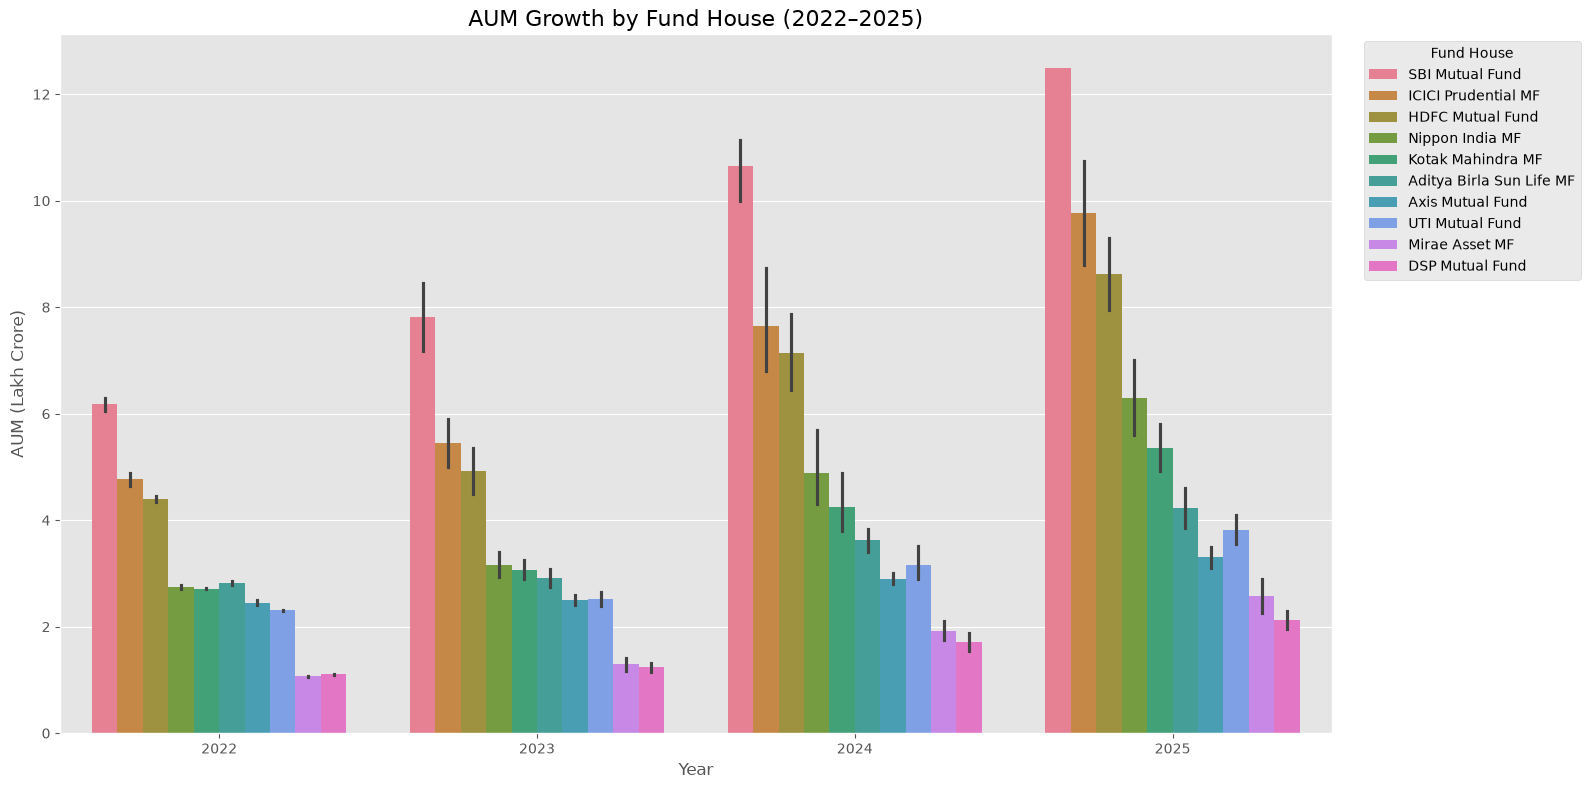

In [21]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

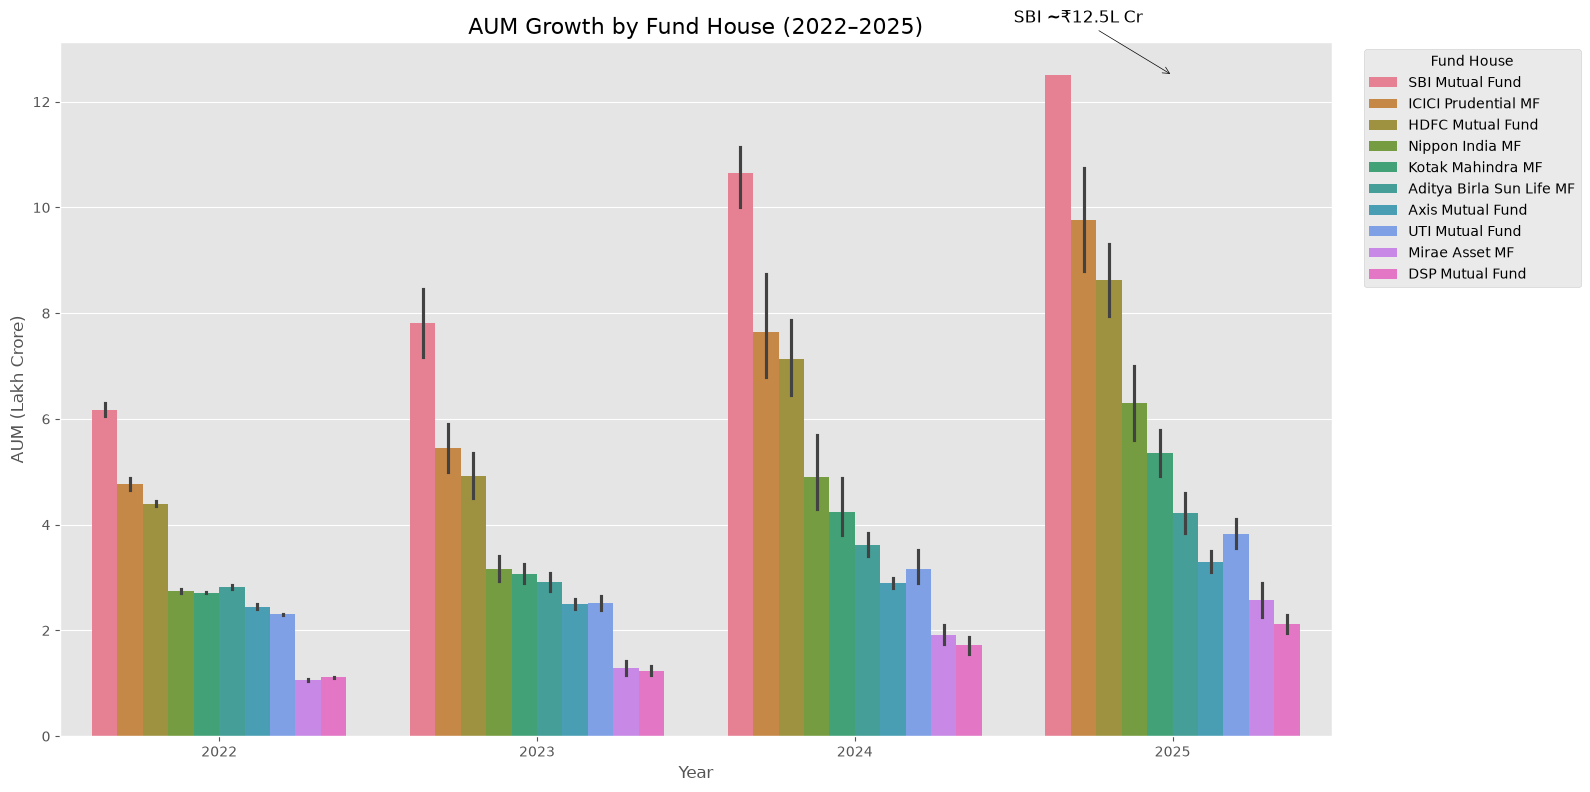

In [22]:
plt.figure(figsize=(16,8))

ax = sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.annotate(
    "SBI ~₹12.5L Cr",
    xy=(3, 12.5),
    xytext=(2.5, 13.5),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=12,
    color="black"
)

plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

In [23]:
plt.savefig("../reports/charts/aum_growth_bar_chart.png", dpi=300)

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [24]:
print(aum["aum_lakh_crore"].max())

12.5


## Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses between 2022 and 2025, reaching approximately ₹12.5 lakh crore by 2025. This indicates its strong market leadership and investor confidence.

# SIP Inflow Trend Analysis

This chart shows the monthly SIP inflows from January 2022 to December 2025.

The highest SIP inflow of ₹31,002 crore in December 2025 is highlighted.

In [25]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.shape)

sip.head()

(48, 6)


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [26]:
# Convert month column to datetime

sip["month"] = pd.to_datetime(sip["month"])

sip.dtypes

month                        datetime64[us]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

In [27]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    markers=True
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified"
)

fig.show()

In [28]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)",
    markers=True
)

# Highest SIP Inflow (Dec 2025)
fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="All-Time High<br>₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-60
)

fig.update_layout(
    width=1200,
    height=600,
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    hovermode="x unified"
)

fig.show()

In [29]:
fig.write_image("../reports/charts/sip_inflow_trend.png")

print("Chart saved successfully!")

Chart saved successfully!


## Insight 3

Monthly SIP inflows showed a steady upward trend from 2022 to 2025, reflecting growing investor participation. The highest monthly SIP inflow reached ₹31,002 crore in December 2025, indicating record investor confidence in mutual fund investments.

# Category Inflow Heatmap

This heatmap visualizes monthly net inflows across different mutual fund categories.

Darker colours indicate higher inflows, while lighter colours represent lower inflows.

In [30]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.shape)

category.head()

(144, 3)


,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [31]:
# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Create Month-Year label
category["month"] = category["month"].dt.strftime("%b-%Y")

category.head()

,month,category,net_inflow_crore
0,Apr-2024,Large Cap,2413.0
1,Apr-2024,Mid Cap,3897.0
2,Apr-2024,Small Cap,3533.0
3,Apr-2024,Flexi Cap,4947.0
4,Apr-2024,Large & Mid Cap,4214.0


In [32]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data


month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0
Large Cap,2413.0,1940.0,1923.0,1925.0,2025.0,2574.0,2519.0,2234.0,2076.0,1870.0,2255.0,1879.0
Liquid,37537.0,41952.0,34933.0,32374.0,33892.0,34643.0,40486.0,38681.0,41872.0,40506.0,39091.0,35308.0
Mid Cap,3897.0,3899.0,5023.0,4819.0,4316.0,4548.0,5047.0,5061.0,5300.0,4336.0,4106.0,4960.0
Sectoral/Thematic,8052.0,8360.0,9820.0,9215.0,7893.0,9896.0,10030.0,8614.0,8354.0,7397.0,7680.0,8518.0


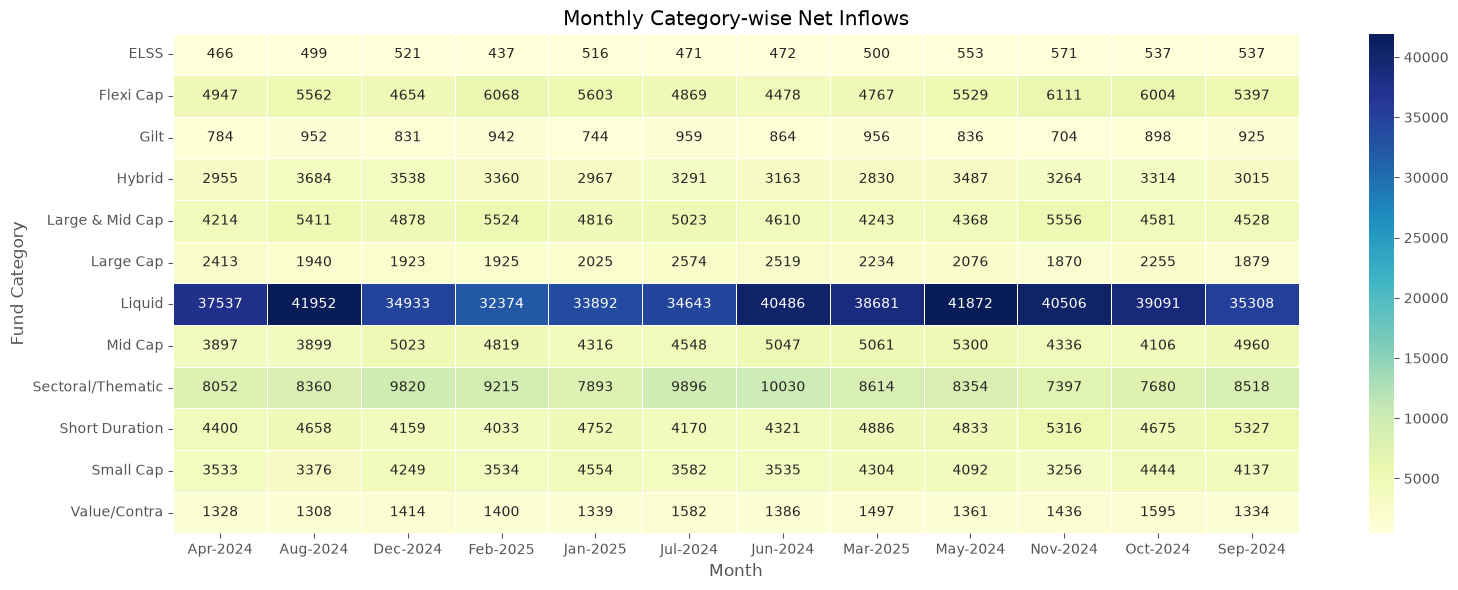

In [33]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflows")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()

In [35]:
plt.tight_layout()

plt.savefig("../reports/charts/category_inflow_heatmap.png", dpi=300)

plt.show()

print("Heatmap saved successfully!")

<Figure size 640x480 with 0 Axes>

Heatmap saved successfully!


## Insight 4

Category-wise inflows varied considerably over time. Flexi Cap, Mid Cap, and Large & Mid Cap funds consistently attracted strong investor inflows during several months, while other categories experienced comparatively lower inflows.

# Investor Demographics Analysis

This section analyzes the demographic profile of mutual fund investors.

The analysis includes:

- Age Group Distribution
- Investment Amount by Age Group
- Gender Distribution

In [36]:
investor = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

print(investor.shape)

investor.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


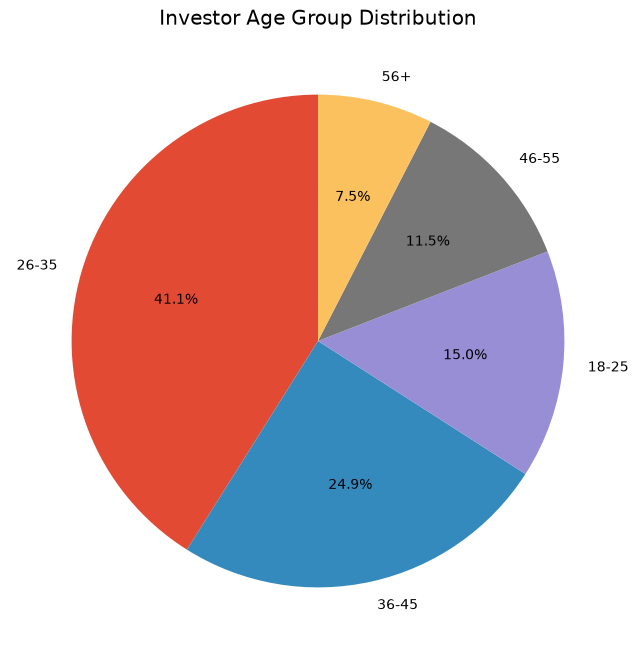

In [37]:
# Count investors by age group
age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

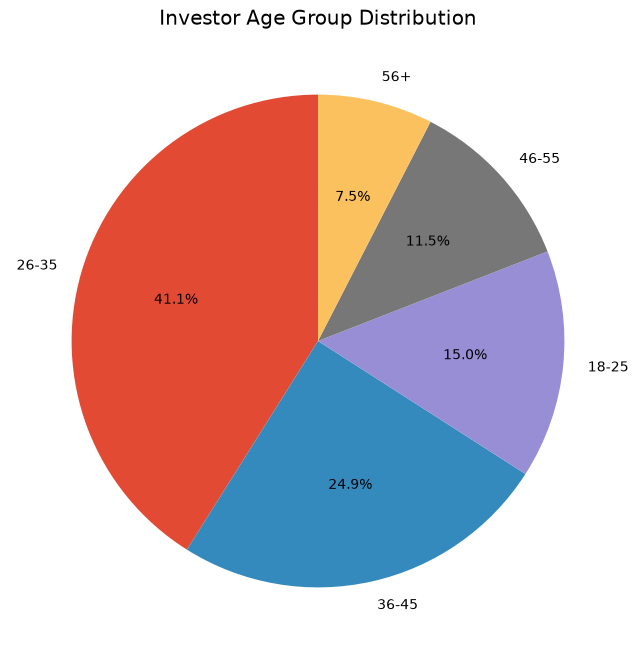

Age Group chart saved successfully!


In [38]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("../reports/charts/age_group_distribution.png", dpi=300)

plt.show()

print("Age Group chart saved successfully!")

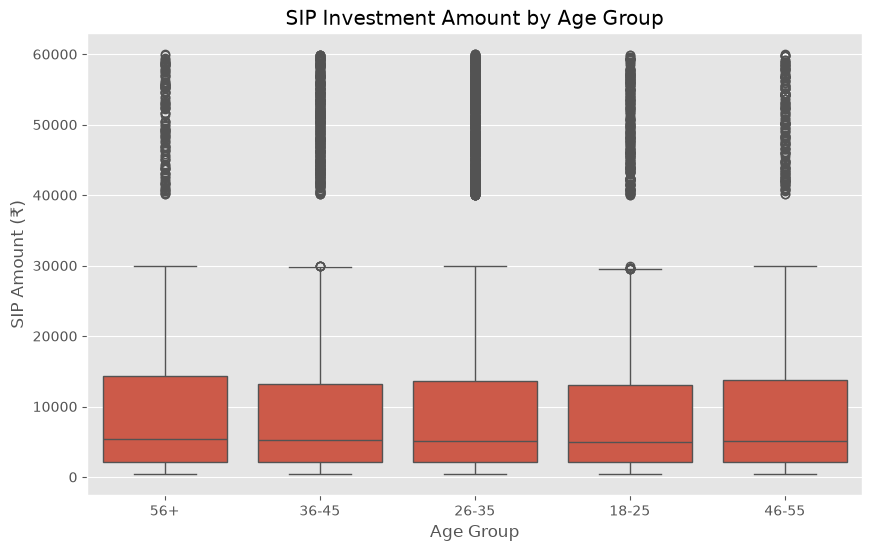

In [39]:
# Filter only SIP transactions
sip_investors = investor[investor["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_investors,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.show()


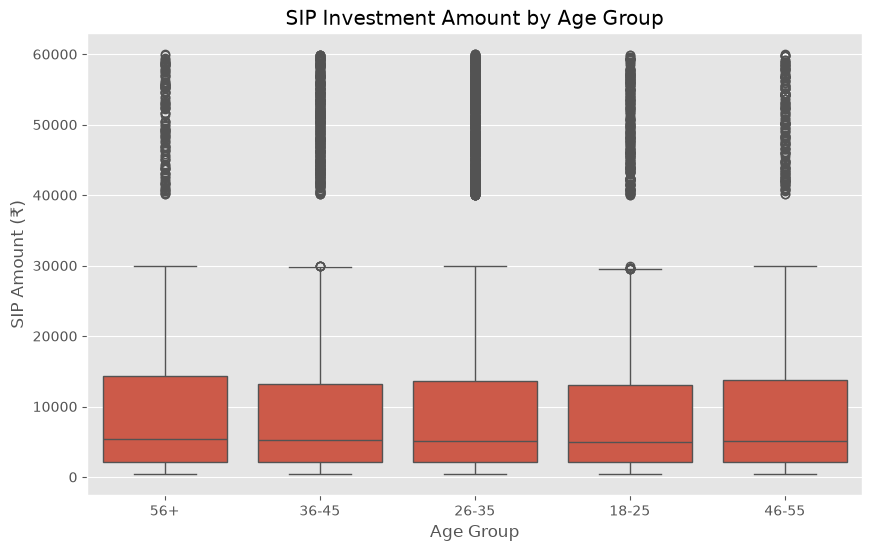

Box Plot saved successfully!


In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_investors,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.savefig("../reports/charts/sip_amount_boxplot.png", dpi=300)

plt.show()

print("Box Plot saved successfully!")

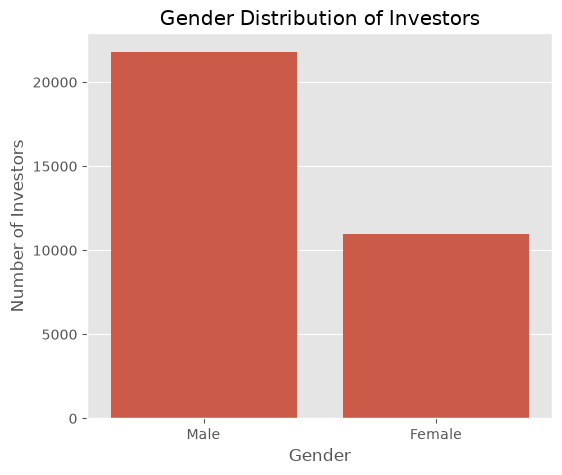

In [41]:
gender_counts = investor["gender"].value_counts()

plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.show()

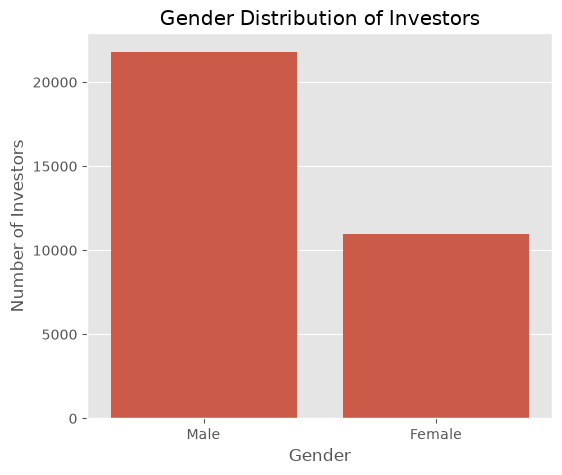

Gender Distribution chart saved successfully!


In [42]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Gender Distribution of Investors")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.savefig("../reports/charts/gender_distribution.png", dpi=300)

plt.show()

print("Gender Distribution chart saved successfully!")

## Insight 5

The investor base is distributed across all age groups, with the 26–45 age range contributing a significant share of investors. SIP investment amounts vary by age group, indicating differences in investment capacity and financial planning. The gender distribution provides an overview of investor participation across male and female investors.

# Geographic Distribution Analysis

This section analyzes the geographical distribution of mutual fund investments across Indian states and city tiers.

The analysis includes:

- SIP Investment Amount by State
- T30 vs B30 City Tier Distribution

In [44]:
# Filter only SIP transactions
sip_data = investor[investor["transaction_type"] == "SIP"]

print(sip_data.shape)

sip_data.head()

(19716, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [45]:
state_sip = (
    sip_data
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head()

state
Madhya Pradesh    20682243
Punjab            20140064
Telangana         18620216
Tamil Nadu        18404368
Gujarat           18378904
Name: amount_inr, dtype: int64

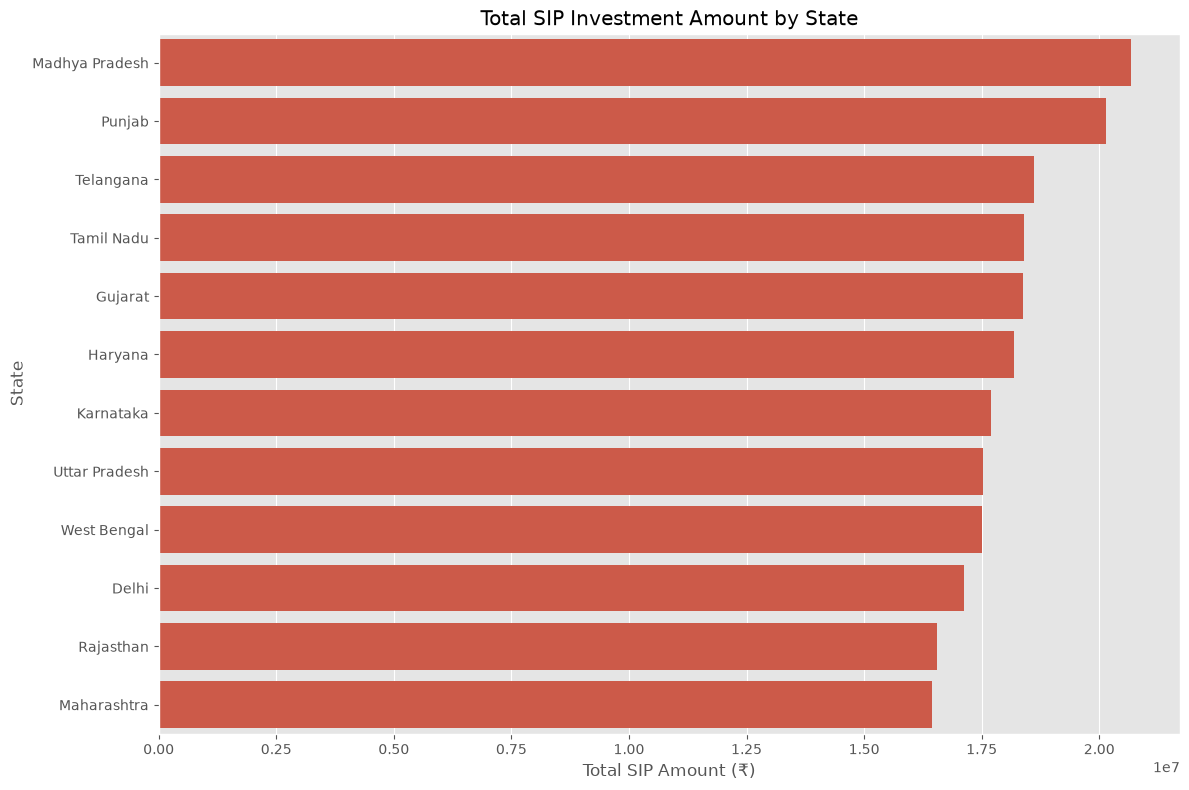

In [46]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

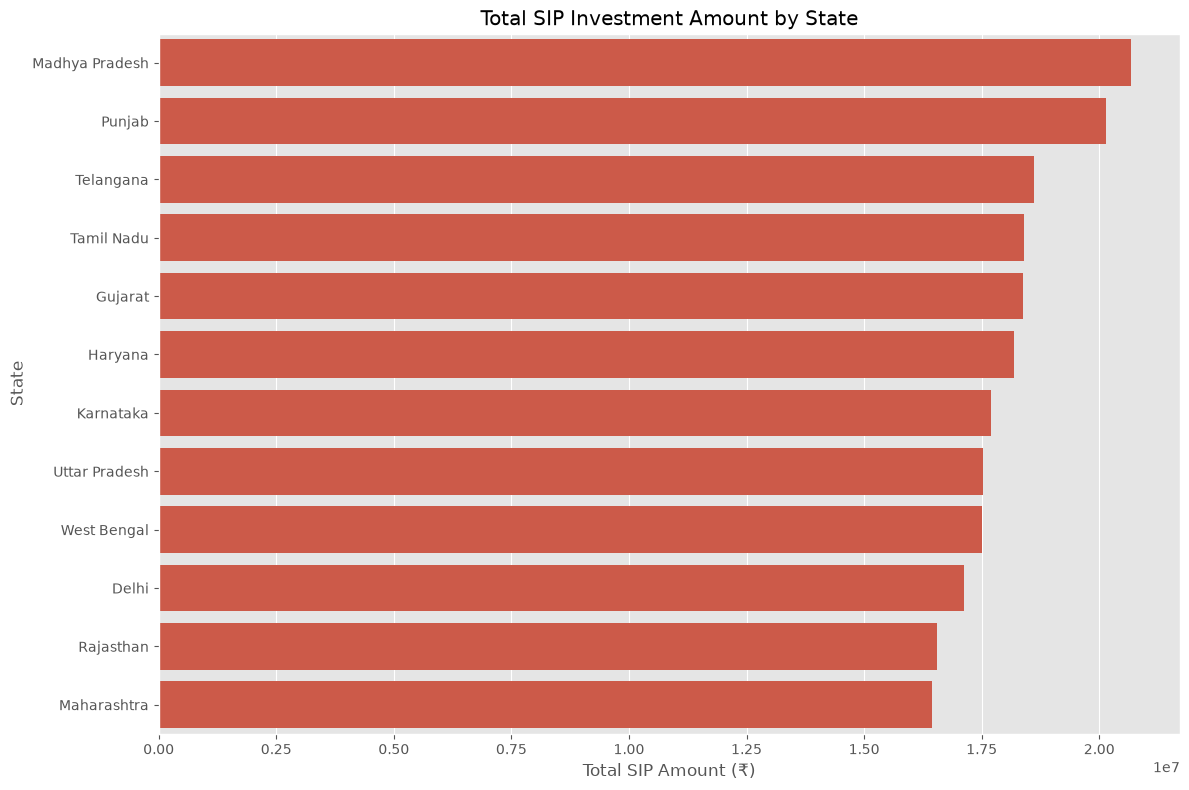

State chart saved successfully!


In [47]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment Amount by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig("../reports/charts/state_sip_distribution.png", dpi=300)

plt.show()

print("State chart saved successfully!")

In [48]:
city_tier = investor["city_tier"].value_counts()

city_tier

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

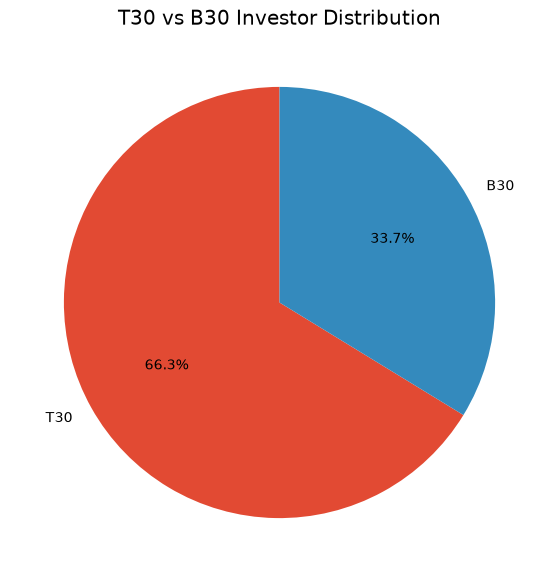

In [49]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

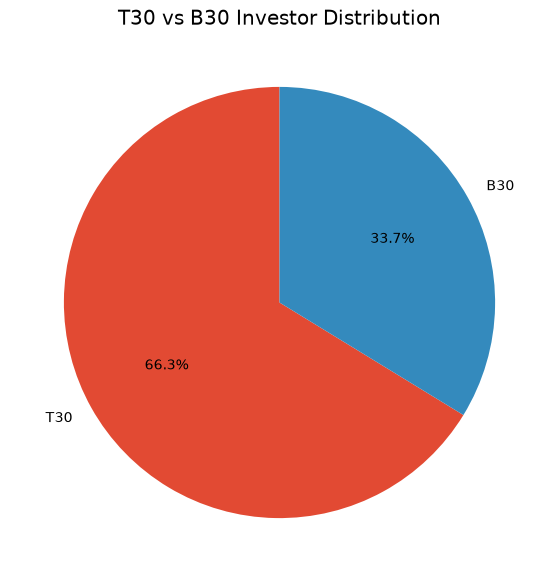

City Tier chart saved successfully!


In [50]:
plt.figure(figsize=(7,7))

plt.pie(
    city_tier,
    labels=city_tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.savefig("../reports/charts/t30_b30_distribution.png", dpi=300)

plt.show()

print("City Tier chart saved successfully!")

## Insight 6

SIP investments are concentrated in a few major states, reflecting stronger participation in regions with higher financial awareness and investment activity. The comparison of T30 and B30 city tiers highlights the spread of mutual fund adoption between metropolitan cities and emerging markets.

# Folio Count Growth Analysis

This visualization shows the growth in mutual fund folio counts from January 2022 to December 2025.

Key milestones are highlighted to demonstrate the increasing participation of investors.

In [51]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.shape)

folio.head()

(21, 6)


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [52]:
# Convert month column to datetime

folio["month"] = pd.to_datetime(folio["month"])

folio.dtypes

month                  datetime64[us]
total_folios_crore            float64
equity_folios_crore           float64
debt_folios_crore             float64
hybrid_folios_crore           float64
others_folios_crore           float64
dtype: object

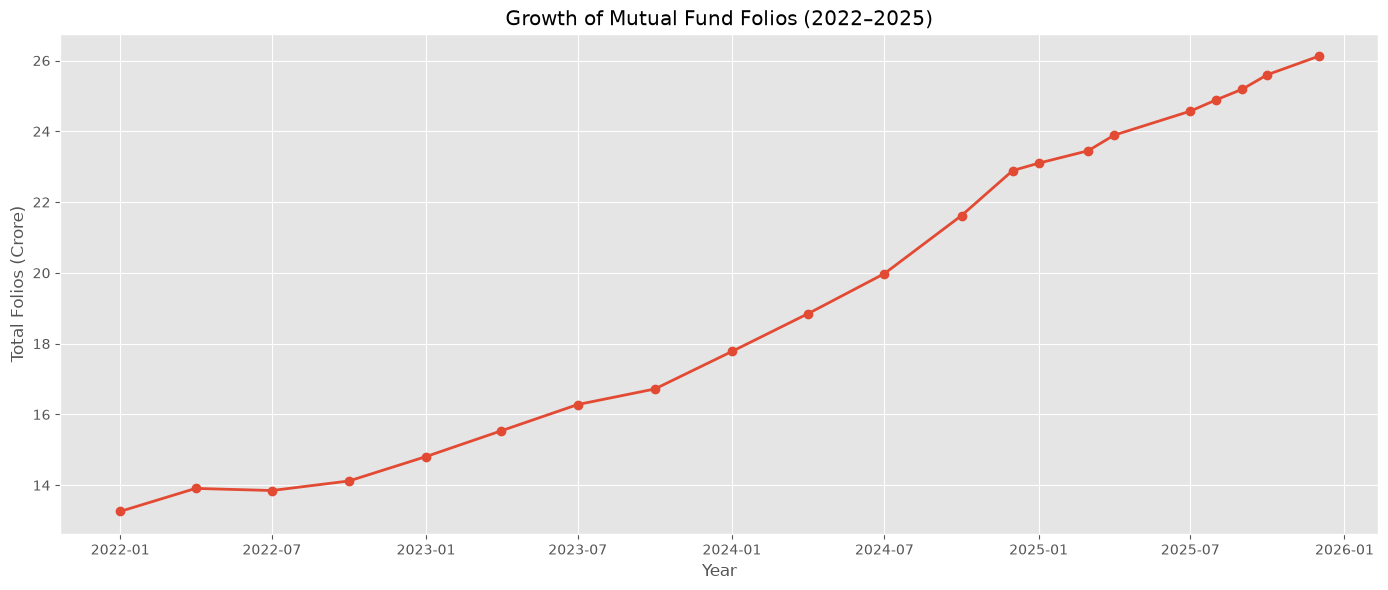

In [53]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

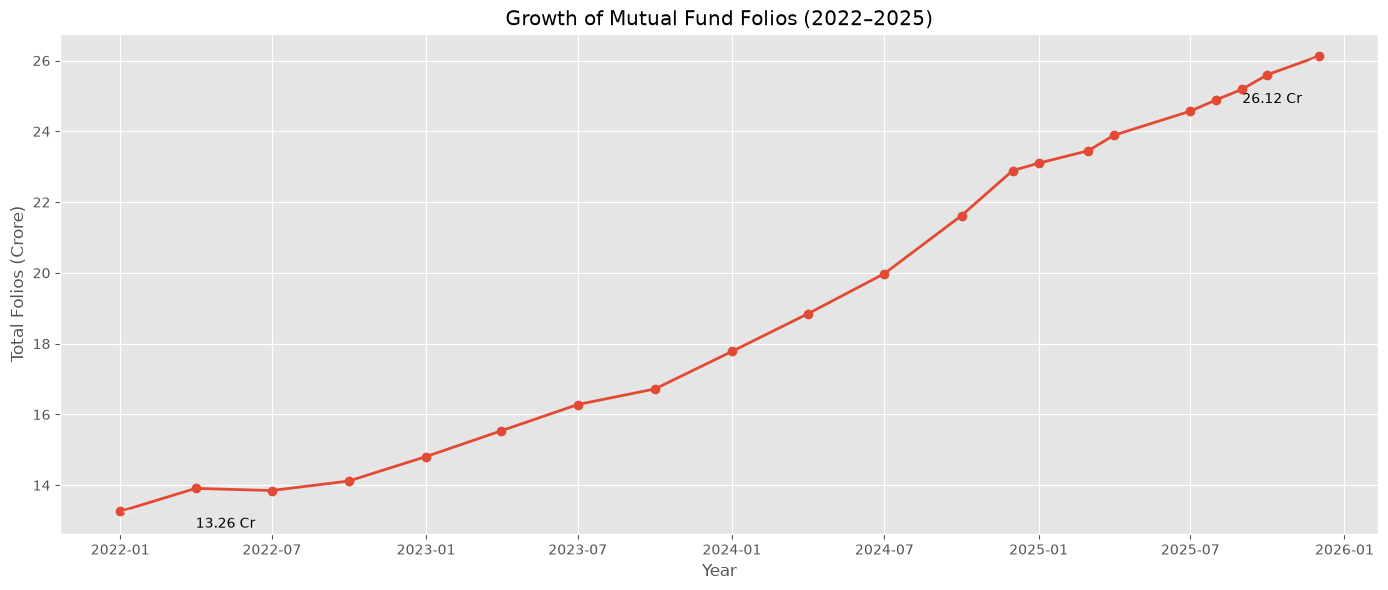

In [54]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

# January 2022
plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(folio["month"].iloc[1], 12.8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# December 2025 (last row)
plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(folio["month"].iloc[-3], 24.8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

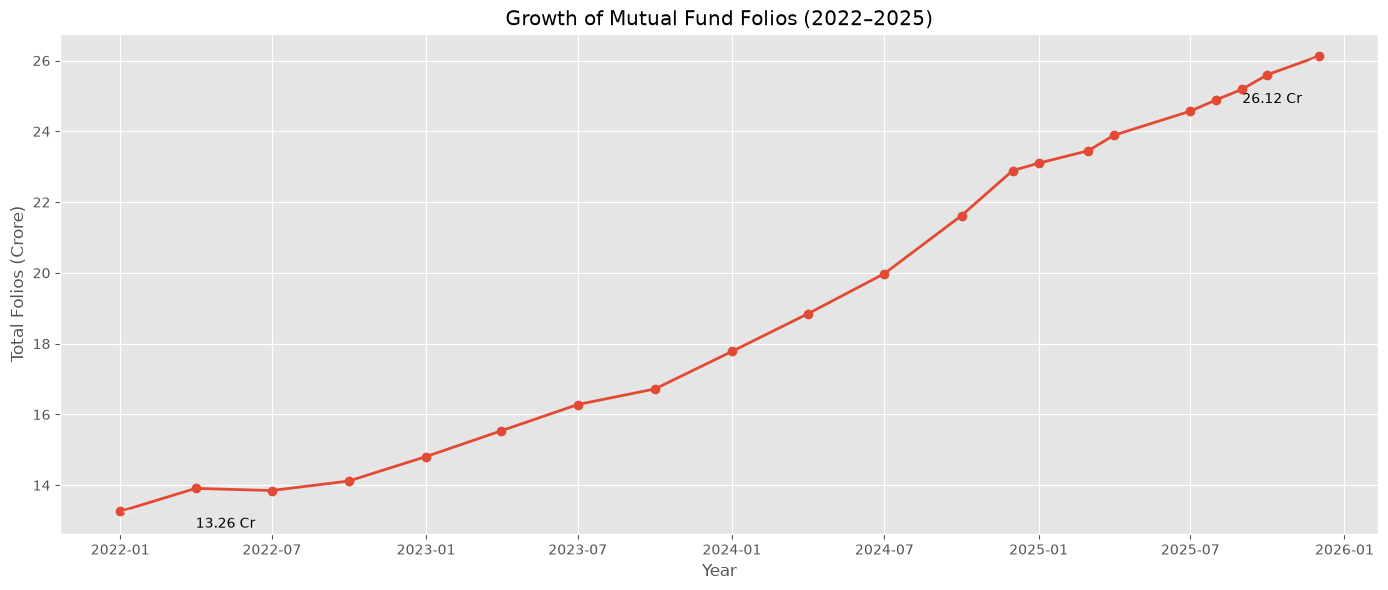

Folio Growth chart saved successfully!


In [55]:
plt.figure(figsize=(14,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0]),
    xytext=(folio["month"].iloc[1], 12.8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1]),
    xytext=(folio["month"].iloc[-3], 24.8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.title("Growth of Mutual Fund Folios (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/charts/folio_growth.png", dpi=300)

plt.show()

print("Folio Growth chart saved successfully!")

## Insight 7

The total number of mutual fund folios nearly doubled from **13.26 crore in January 2022** to approximately **26.12 crore by the end of 2025**. This sustained growth reflects increasing investor participation and wider adoption of mutual funds across India.

# NAV Return Correlation Analysis

This analysis measures the correlation between the daily returns of selected mutual fund schemes.

A higher correlation indicates that two funds tend to move together, while a lower correlation suggests more independent performance.


In [56]:
# Select first 10 mutual fund schemes

selected_schemes = nav["scheme_name"].unique()[:10]

selected_nav = nav[
    nav["scheme_name"].isin(selected_schemes)
]

selected_nav.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [57]:
pivot_nav = selected_nav.pivot(
    index="date",
    columns="scheme_name",
    values="nav"
)

pivot_nav.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,305.0996,310.7415,38.5736,107.3758,26.3169,520.4608,42.8339,191.0721,119.2905,89.8728
2022-01-04,305.4514,310.6977,38.1545,105.9447,26.2234,515.0971,42.8033,189.0737,120.6402,90.8724
2022-01-05,306.6324,310.8165,38.1775,105.4800,26.2221,521.7239,43.0564,188.0701,121.4580,90.1565
2022-01-06,305.9800,310.7719,37.0665,104.9350,26.1728,515.7880,43.2088,190.4545,125.2386,91.5338
2022-01-07,304.0480,310.8388,37.9845,104.3318,26.2261,515.1639,42.9585,187.3124,124.1321,90.6762


In [58]:
daily_returns = pivot_nav.pct_change()

daily_returns.head()

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001153,-0.000141,-0.010865,-0.013328,-0.003553,-0.010306,-0.000714,-0.010459,0.011314,0.011122
2022-01-05,0.003866,0.000382,0.000603,-0.004386,-0.000050,0.012865,0.005913,-0.005308,0.006779,-0.007878
2022-01-06,-0.002128,-0.000143,-0.029101,-0.005167,-0.001880,-0.011377,0.003540,0.012678,0.031127,0.015277
2022-01-07,-0.006314,0.000215,0.024766,-0.005748,0.002036,-0.001210,-0.005793,-0.016498,-0.008835,-0.009369


In [59]:
correlation = daily_returns.corr()

correlation

scheme_name,ABSL Frontline Equity Fund - Regular - Growth,ABSL Liquid Fund - Regular - Growth,ABSL Small Cap Fund - Regular - Growth,HDFC Mid-Cap Opportunities Fund - Regular - Growth,HDFC Short Term Debt Fund - Regular - Growth,HDFC Top 100 Fund - Regular Plan - Growth,Nippon India Large Cap Fund - Regular - Growth,UTI Flexi Cap Fund - Regular - Growth,UTI Mid Cap Fund - Regular - Growth,UTI Nifty 50 Index Fund - Regular - Growth
scheme_name,,,,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,1.000000,-0.027230,0.010202,-0.018079,0.023769,0.027747,-0.005432,-0.006490,0.007229,0.001570
ABSL Liquid Fund - Regular - Growth,-0.027230,1.000000,-0.007530,0.007864,0.018455,-0.033773,0.003507,0.036547,0.014307,-0.001436
ABSL Small Cap Fund - Regular - Growth,0.010202,-0.007530,1.000000,0.000351,-0.006710,0.016053,0.043384,0.002304,0.004860,-0.005929
HDFC Mid-Cap Opportunities Fund - Regular - Growth,-0.018079,0.007864,0.000351,1.000000,0.002150,-0.000006,-0.013318,-0.036647,-0.018166,-0.034228
HDFC Short Term Debt Fund - Regular - Growth,0.023769,0.018455,-0.006710,0.002150,1.000000,0.045567,-0.014166,-0.005648,0.013754,-0.001038
HDFC Top 100 Fund - Regular Plan - Growth,0.027747,-0.033773,0.016053,-0.000006,0.045567,1.000000,-0.026781,-0.023316,-0.005867,-0.093533
Nippon India Large Cap Fund - Regular - Growth,-0.005432,0.003507,0.043384,-0.013318,-0.014166,-0.026781,1.000000,0.001248,-0.039886,-0.000285
UTI Flexi Cap Fund - Regular - Growth,-0.006490,0.036547,0.002304,-0.036647,-0.005648,-0.023316,0.001248,1.000000,-0.007865,-0.036704
UTI Mid Cap Fund - Regular - Growth,0.007229,0.014307,0.004860,-0.018166,0.013754,-0.005867,-0.039886,-0.007865,1.000000,0.020691


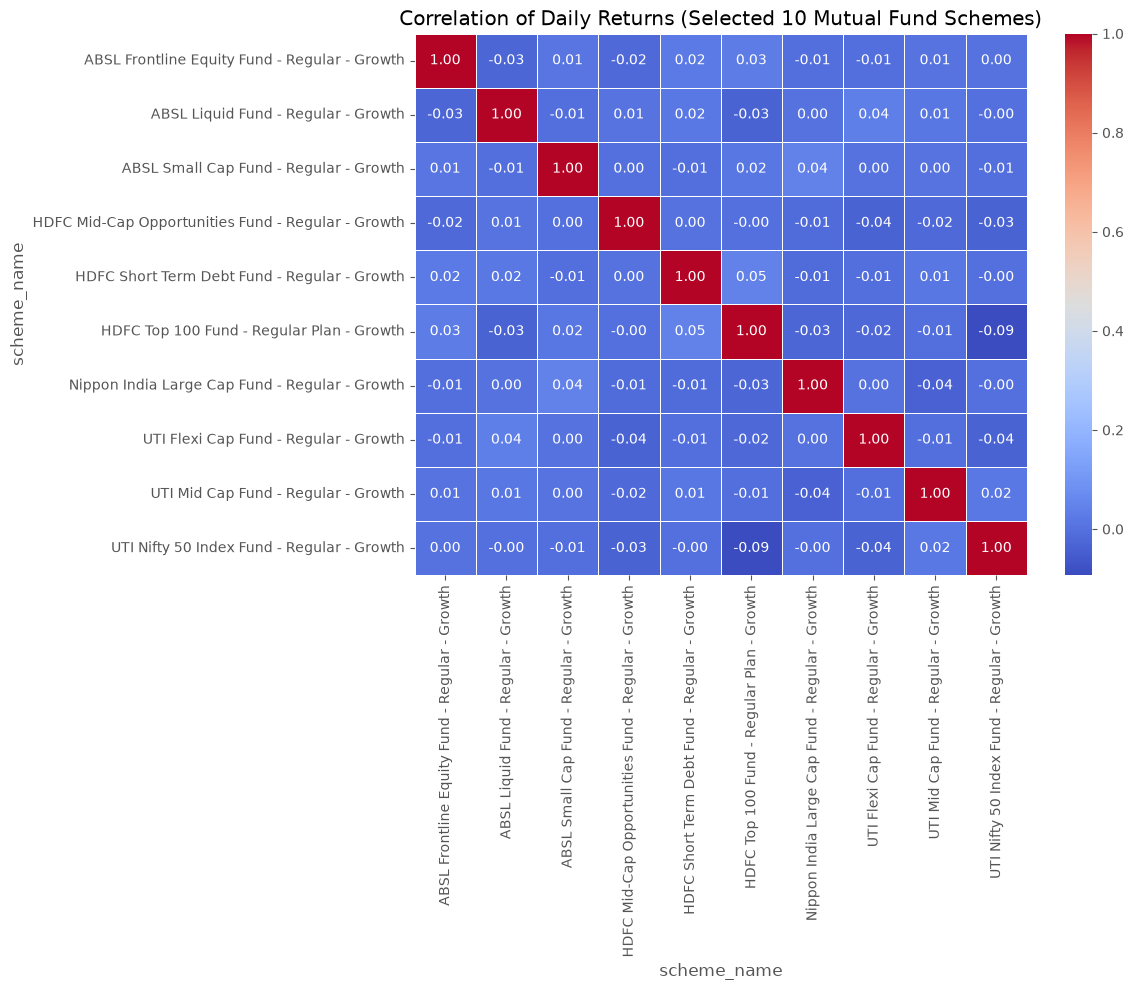

In [60]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation of Daily Returns (Selected 10 Mutual Fund Schemes)")

plt.tight_layout()

plt.show()

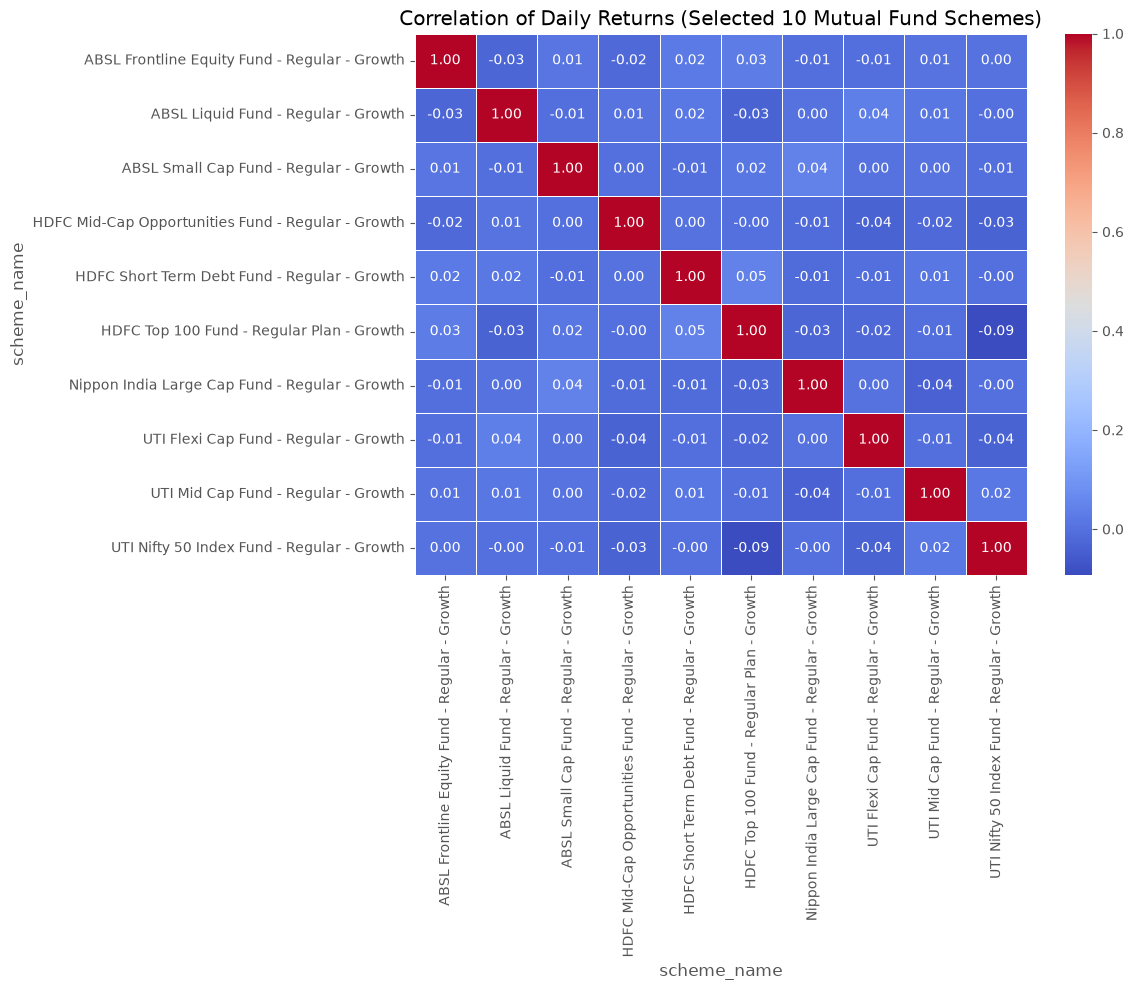

Correlation Heatmap saved successfully!


In [61]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation of Daily Returns (Selected 10 Mutual Fund Schemes)")

plt.tight_layout()

plt.savefig("../reports/charts/nav_return_correlation.png", dpi=300)

plt.show()

print("Correlation Heatmap saved successfully!")

## Insight 8

The correlation matrix shows that several large-cap mutual fund schemes exhibit strong positive correlations, indicating similar market behaviour. Lower correlations among certain funds suggest diversification opportunities for investors.

# Sector Allocation Analysis

This visualization shows the aggregate portfolio allocation across different sectors for all equity mutual funds.

The donut chart highlights the relative weight of each sector in the combined portfolio.

In [62]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.shape)

portfolio.head()

(322, 8)


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [63]:
# Aggregate sector allocation
sector_data = (
    portfolio
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

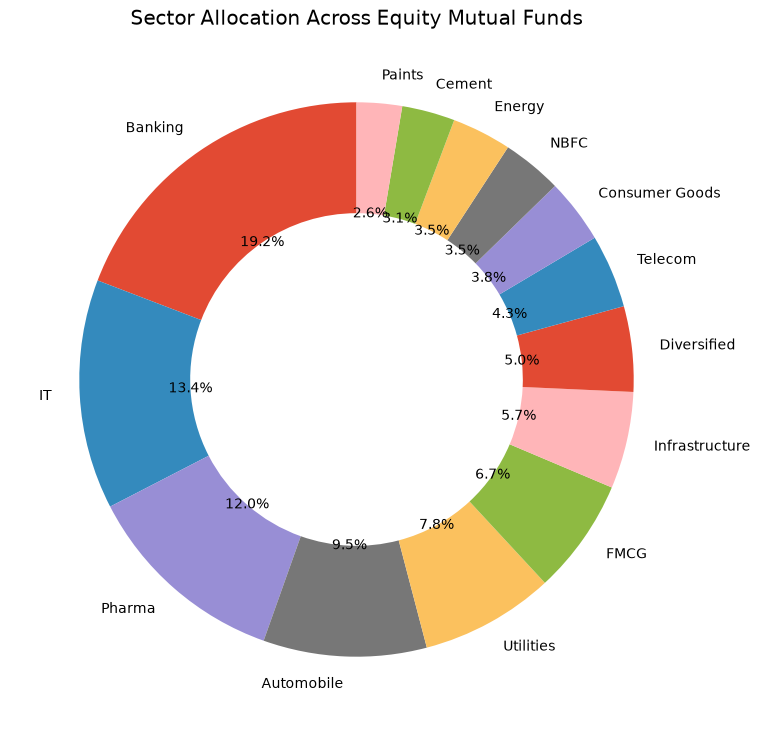

In [64]:
plt.figure(figsize=(9,9))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.show()

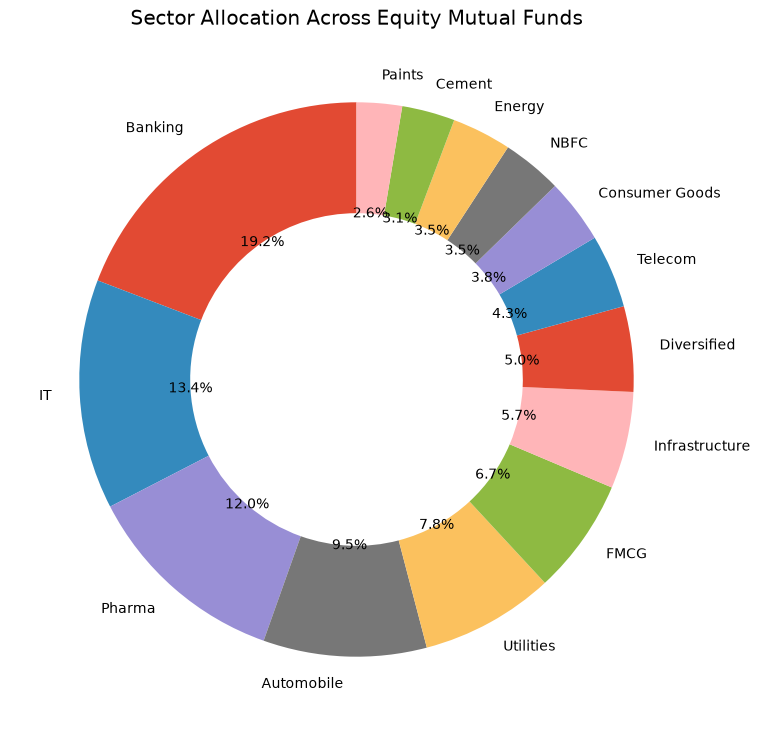

Sector Allocation chart saved successfully!


In [65]:
plt.figure(figsize=(9,9))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.savefig("../reports/charts/sector_allocation_donut.png", dpi=300)

plt.show()

print("Sector Allocation chart saved successfully!")

## Insight 9

The combined portfolio allocation shows that sectors such as Banking, Information Technology, Pharma, and Utilities account for a significant share of equity mutual fund investments. This reflects the preference of fund managers for sectors with strong long-term growth potential and market stability.

# Overall EDA Summary

## Insight 10

The exploratory data analysis indicates consistent growth in India's mutual fund industry between 2022 and 2025. Rising SIP inflows, increasing folio counts, expanding AUM, and broad investor participation across regions and age groups demonstrate strong market confidence. Correlation analysis and sector allocation further highlight diversification opportunities and investment patterns across mutual fund schemes.